In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sentence_transformers import SentenceTransformer

# 1. Wczytanie danych
df = pd.read_csv("../data/reviews.csv") 
# Oczyszczamy z pustych wierszy
df = df.dropna(subset=['review'])

X = df['review'].tolist()
y = df['voted_up'].astype(int).tolist() # True/False zamieniamy na 1/0

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Pobranie wielojęzycznego modelu do osadzeń (zajmie chwilę przy pierwszym uruchomieniu)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("Generowanie wektorów dla opinii (embedding)...")
X_train_embeddings = model.encode(X_train)
X_test_embeddings = model.encode(X_test)

# 3. Trening klasyfikatora
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_embeddings, y_train)

# 4. Ewaluacja modelu
y_pred = clf.predict(X_test_embeddings)
print(classification_report(y_test, y_pred))

c:\Users\karol\repos\dsai-final-project\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\karol\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5802.30

Generowanie wektorów dla opinii (embedding)...
              precision    recall  f1-score   support

           0       0.75      0.71      0.73       187
           1       0.76      0.79      0.78       214

    accuracy                           0.76       401
   macro avg       0.76      0.75      0.75       401
weighted avg       0.76      0.76      0.76       401



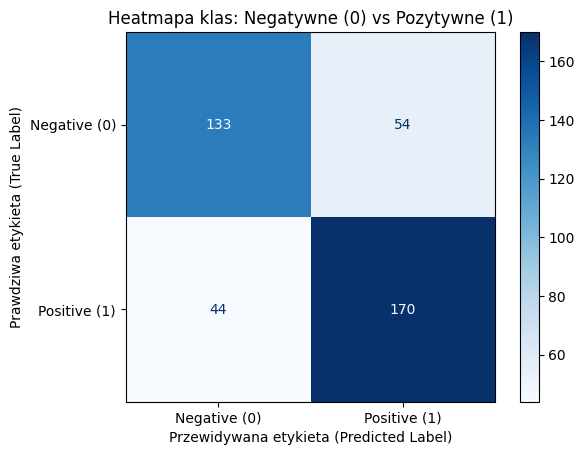

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generujemy macierz pomyłek na podstawie prawdziwych i przewidzianych etykiet
cm = confusion_matrix(y_test, y_pred)

# 2. Tworzymy i wyświetlamy heat mapę
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative (0)', 'Positive (1)'])

# Możesz zmienić kolorystykę, np. na plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens
disp.plot(cmap=plt.cm.Blues, values_format='d') 

plt.title("Heatmapa klas: Negatywne (0) vs Pozytywne (1)")
plt.ylabel("Prawdziwa etykieta (True Label)")
plt.xlabel("Przewidywana etykieta (Predicted Label)")
plt.show()

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Wczytanie i podział danych
df = pd.read_csv("../data/reviews.csv").dropna(subset=['review'])
X = df['review'].tolist()
y = df['voted_up'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Generowanie osadzeń (nasze cechy wejściowe X)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
X_train_emb = model.encode(X_train)
X_test_emb = model.encode(X_test)

# 3. Budowa architektury sieci w Keras
model_keras = Sequential([
    # Warstwa wejściowa dopasowana do rozmiaru embeddingu (384)
    Dense(128, activation='relu', input_shape=(X_train_emb.shape[1],)),
    Dropout(0.3), # Ochrona przed przeuczeniem (overfittingiem)
    Dense(64, activation='relu'),
    Dropout(0.2),
    # Warstwa wyjściowa dla klasyfikacji binarnej (sigmoid daje wynik od 0 do 1)
    Dense(1, activation='sigmoid')
])

# 4. Kompilacja modelu
model_keras.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 5. Trening sieci
print("Trwa trening sieci w Keras...")
history = model_keras.fit(
    X_train_emb, y_train, 
    epochs=10,            # Liczba przejść przez cały zbiór
    batch_size=32,        # Rozmiar paczki danych
    validation_split=0.1, # Wewnętrzna walidacja w locie
    verbose=1
)

# 6. Ewaluacja na zbiorze testowym
loss, accuracy = model_keras.evaluate(X_test_emb, y_test)
print(f"Dokładność (Accuracy) na zbiorze testowym: {accuracy:.4f}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3899.91it/s]


Trwa trening sieci w Keras...
Epoch 1/10


c:\Users\karol\repos\dsai-final-project\.venv_keras\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6861 - loss: 0.6089 - val_accuracy: 0.7500 - val_loss: 0.5239
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7472 - loss: 0.5214 - val_accuracy: 0.7688 - val_loss: 0.4954
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7694 - loss: 0.4899 - val_accuracy: 0.7500 - val_loss: 0.4822
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7826 - loss: 0.4720 - val_accuracy: 0.7812 - val_loss: 0.4714
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7965 - loss: 0.4543 - val_accuracy: 0.7625 - val_loss: 0.4675
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8069 - loss: 0.4226 - val_accuracy: 0.7625 - val_loss: 0.4572
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8208 - loss: 0.3961 - val_accuracy: 0.7375 - val_loss: 0.4712
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8403 - loss: 0.3708 - val_accuracy: 0.7500 - val_loss: 0.4676
Epo

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Raport klasyfikacji dla modelu Keras:
              precision    recall  f1-score   support

           0       0.78      0.66      0.71       187
           1       0.74      0.83      0.78       214

    accuracy                           0.75       401
   macro avg       0.76      0.75      0.75       401
weighted avg       0.76      0.75      0.75       401



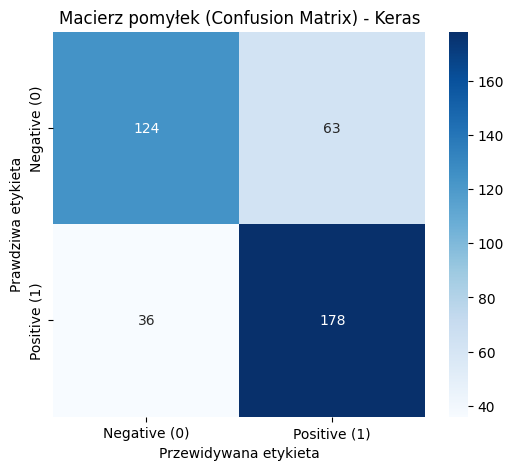

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Uzyskanie prawdopodobieństw dla zbioru testowego
y_pred_probs = model_keras.predict(X_test_emb)

# Konwersja prawdopodobieństw na etykiety binarne (0 lub 1)
y_pred_keras = (y_pred_probs > 0.5).astype(int).flatten()

# Wyświetlenie dokładnego raportu (Precision, Recall, F1-score)
print("Raport klasyfikacji dla modelu Keras:")
print(classification_report(y_test, y_pred_keras))

# Wyliczenie macierzy pomyłek
cm_keras = confusion_matrix(y_test, y_pred_keras)

# Rysowanie heat mapy dla modelu Keras
plt.figure(figsize=(6, 5))
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'], 
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title("Macierz pomyłek (Confusion Matrix) - Keras")
plt.ylabel("Prawdziwa etykieta")
plt.xlabel("Przewidywana etykieta")
plt.show()

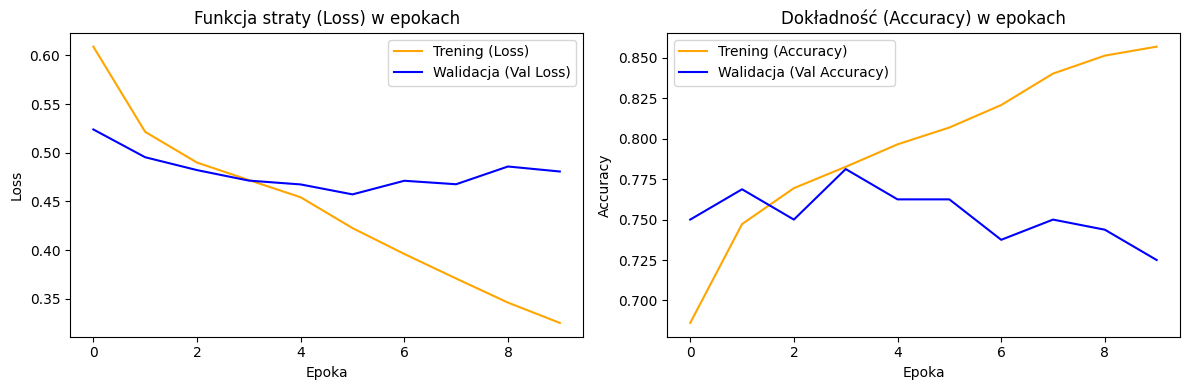

In [6]:
# Wykres funkcji straty (Loss)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Trening (Loss)', color='orange')
plt.plot(history.history['val_loss'], label='Walidacja (Val Loss)', color='blue')
plt.title('Funkcja straty (Loss) w epokach')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()

# Wykres dokładności (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Trening (Accuracy)', color='orange')
plt.plot(history.history['val_accuracy'], label='Walidacja (Val Accuracy)', color='blue')
plt.title('Dokładność (Accuracy) w epokach')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()